In [1]:
from core.sr_study_analysis import run_analysis, run_selected_configs, ExperimentSpec
from core.sr_sim import StudyType

## Scenarios and parameter grids

In [2]:
from core.dgp import IIDProcess, SkewTInnov, APDInnov
from core.sr_study_analysis import set_extra_dgps

DGP_EXAMPLES: dict[str, callable] = {
    "apd_base": (
        lambda **kwargs: IIDProcess(APDInnov(alpha=0.7, lam=1.35))
    ),
    "apd_pos_skew": (
        lambda lam: IIDProcess(APDInnov(alpha=0.1, lam=lam))
    ),
    "apd_neg_skew": (
        lambda lam: IIDProcess(APDInnov(alpha=0.9, lam=lam))
    ),
}
set_extra_dgps(DGP_EXAMPLES)


In [3]:
# name : (dgp_names, model_short_names)
scenarios = {
    "...": (
        ["apd_base"],
        ["iid_nonnormal"],
    ),
}

parameters = {
    "sr":    [0.5, 1.0, 1.5],
    "T":     [100, 500, 2_000],
    "n_sim": [1_000, 3_000, 10_000],
}

## Experiment registry

Each entry is an `ExperimentSpec`.  
Set `study_type` to one of:
- `StudyType.TWO_SIDED_COVERAGE` / `ONE_SIDED_COVERAGE`  — size / coverage runs  
- `StudyType.TWO_SIDED_POWER`    / `ONE_SIDED_POWER`     — power runs (requires `null_sr`)

In [4]:
N_SIM  = 10_000
N_JOBS = 8

experiments = {
    "table1_a_nadj": ExperimentSpec(
        scenario   = (["apd_base"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        sr_default = 0.0,
        n_default = N_SIM, n_jobs = N_JOBS,
    ),
    "table1_b_nadj": ExperimentSpec(
        scenario   = (["apd_base"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        sr_default = 1.0,
        n_default  = N_SIM, n_jobs = N_JOBS,
    ),
    "fig5_b": ExperimentSpec(
        scenario   = (["apd_pos_skew"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        sr_default = 3.0,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = "lam",
        label_values = [1.0, 1.25, 1.50, 1.75, 2.0],
    ),
    "fig5_d": ExperimentSpec(
        scenario   = (["apd_neg_skew"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        sr_default = 3.0,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = "lam",
        label_values = [1.0, 1.25, 1.50, 1.75, 2.0],
    ),
    "aux":ExperimentSpec(
        scenario     = (["apd"],["iid_nonnormal"]),
        param_name   = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type   = StudyType.ONE_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments=False,
        sr_default = 1.0,
        n_default  = N_SIM,
        n_jobs     = N_JOBS,
        label_param  = "null_sr",          # ← new
        label_values = [0.0, 0.2, 1.0, 3.0],  # ← new
    )
}

---
## EXECUTION

In [10]:
# ── coverage / size runs ──────────────────────────────────────────────────────
run_selected_configs(
    experiments,
    selected_experiments=[
        #"base",
        #"fig5_b",
        "fig5_d",
        #"aux",
    ],
)


  Experiment: fig5_d
  [1/25]  T=15  lam=1.0  (ONE_SIDED_COVERAGE)
  [2/25]  T=30  lam=1.0  (ONE_SIDED_COVERAGE)
  [3/25]  T=50  lam=1.0  (ONE_SIDED_COVERAGE)
  [4/25]  T=100  lam=1.0  (ONE_SIDED_COVERAGE)
  [5/25]  T=300  lam=1.0  (ONE_SIDED_COVERAGE)
  [6/25]  T=15  lam=1.25  (ONE_SIDED_COVERAGE)
  [7/25]  T=30  lam=1.25  (ONE_SIDED_COVERAGE)
  [8/25]  T=50  lam=1.25  (ONE_SIDED_COVERAGE)
  [9/25]  T=100  lam=1.25  (ONE_SIDED_COVERAGE)
  [10/25]  T=300  lam=1.25  (ONE_SIDED_COVERAGE)
  [11/25]  T=15  lam=1.5  (ONE_SIDED_COVERAGE)
  [12/25]  T=30  lam=1.5  (ONE_SIDED_COVERAGE)
  [13/25]  T=50  lam=1.5  (ONE_SIDED_COVERAGE)
  [14/25]  T=100  lam=1.5  (ONE_SIDED_COVERAGE)
  [15/25]  T=300  lam=1.5  (ONE_SIDED_COVERAGE)
  [16/25]  T=15  lam=1.75  (ONE_SIDED_COVERAGE)
  [17/25]  T=30  lam=1.75  (ONE_SIDED_COVERAGE)
  [18/25]  T=50  lam=1.75  (ONE_SIDED_COVERAGE)
  [19/25]  T=100  lam=1.75  (ONE_SIDED_COVERAGE)
  [20/25]  T=300  lam=1.75  (ONE_SIDED_COVERAGE)
  [21/25]  T=15  lam=2.0  (ON

---
## VISUALIZATION — Coverage / Size

In [6]:
#common
line_plot_kargs = dict(reverse=True, 
                       markers = ['D', 's', 'o', 'X', 'v'],
                       palette = ['black'],
                       linewidth=1,
                       yticks=[0.00, 0.05, 0.10, 0.15, 0.20, 0.25])

In [7]:
#run_analysis(experiments, "table1_a_nadj", alpha=0.05, line_plot_kargs=line_plot_kargs)

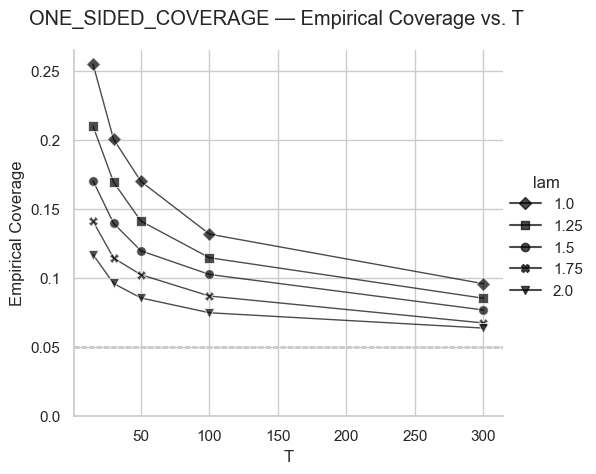

In [8]:
run_analysis(experiments, "fig5_b", alpha=0.05, plot_mask=[0,0,1], line_plot_kargs=line_plot_kargs)

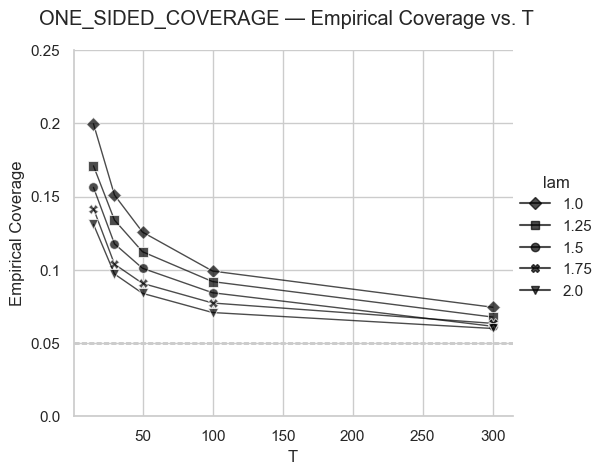

In [9]:
run_analysis(experiments, "fig5_d", alpha=0.05, plot_mask=[0,0,1], line_plot_kargs=line_plot_kargs)